# Group 14 A4 Formative Task

## Project Title
Green Space Distribution Equity in Greater Melbourne

## Research Question
How evenly is open space distributed across SA2 areas in Greater Melbourne?

In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

In [4]:
sa2 = gpd.read_file(
    "/Users/gerald/Desktop/data_raw/abs_boundary/ASGS_2021_Main_Structure_GDA2020.gpkg",
    layer="SA2_2021_AUST_GDA2020"
)

open_space = gpd.read_file(
    "/Users/gerald/Desktop/data_raw/open_space/VPA_Draft_Open_Space_Data_-7361858239455755329.geojson"
)

print(sa2.shape)
print(open_space.shape)

(2473, 17)
(38810, 23)


361


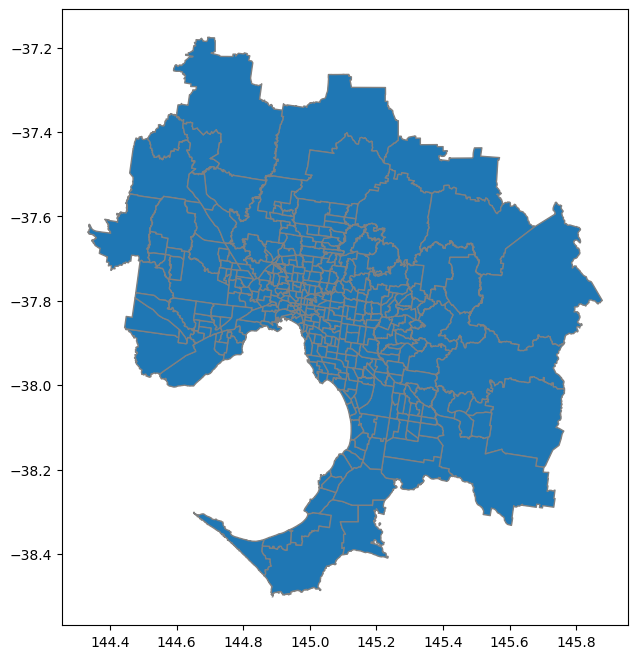

In [5]:
melb = sa2[
    sa2["GCCSA_NAME_2021"]=="Greater Melbourne"
].copy()

print(len(melb))

melb.plot(
    figsize=(8,8),
    edgecolor="grey"
)

plt.show()

In [6]:
melb=melb.to_crs(7855)
open_space=open_space.to_crs(7855)

melb["sa2_area"]=melb.geometry.area

overlay=gpd.overlay(
    open_space,
    melb[
        [
            "SA2_CODE_2021",
            "geometry"
        ]
    ],
    how="intersection"
)

overlay["open_area"]=overlay.area

summary=(
    overlay
    .groupby(
        "SA2_CODE_2021"
    )
    ["open_area"]
    .sum()
    .reset_index()
)

melb=melb.merge(
    summary,
    on="SA2_CODE_2021",
    how="left"
)

melb["open_area"]=(
    melb["open_area"]
    .fillna(0)
)

melb["coverage"]=(
    melb["open_area"]
    /
    melb["sa2_area"]
)*100

melb.head()

,SA2_CODE_2021,SA2_NAME_2021,CHANGE_FLAG_2021,CHANGE_LABEL_2021,SA3_CODE_2021,SA3_NAME_2021,SA4_CODE_2021,SA4_NAME_2021,GCCSA_CODE_2021,GCCSA_NAME_2021,STATE_CODE_2021,STATE_NAME_2021,AUS_CODE_2021,AUS_NAME_2021,AREA_ALBERS_SQKM,ASGS_LOCI_URI_2021,geometry,sa2_area,open_area,coverage
0,206011106,Brunswick East,0,No change,20601,Brunswick - Coburg,206,Melbourne - Inner,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,2.1682,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((321462.804 5818449.962, 321462...",2.167998e+06,359930.756567,16.601984
1,206011107,Brunswick West,0,No change,20601,Brunswick - Coburg,206,Melbourne - Inner,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,3.1795,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((318017.323 5818838.78, 318016....",3.178667e+06,300615.659812,9.457287
2,206011109,Pascoe Vale South,0,No change,20601,Brunswick - Coburg,206,Melbourne - Inner,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,2.9887,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((317848.49 5820770.142, 317883....",2.988928e+06,249975.186110,8.363372
3,206011495,Brunswick - North,1,New,20601,Brunswick - Coburg,206,Melbourne - Inner,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,2.4091,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((319443.585 5819047.655, 319432...",2.408738e+06,31290.098970,1.299024
4,206011496,Brunswick - South,1,New,20601,Brunswick - Coburg,206,Melbourne - Inner,2GMEL,Greater Melbourne,2,Victoria,AUS,Australia,2.7334,http://linked.data.gov.au/dataset/asgsed3/SA2/...,"MULTIPOLYGON (((319433.185 5817708.481, 319411...",2.733708e+06,309324.249151,11.315190


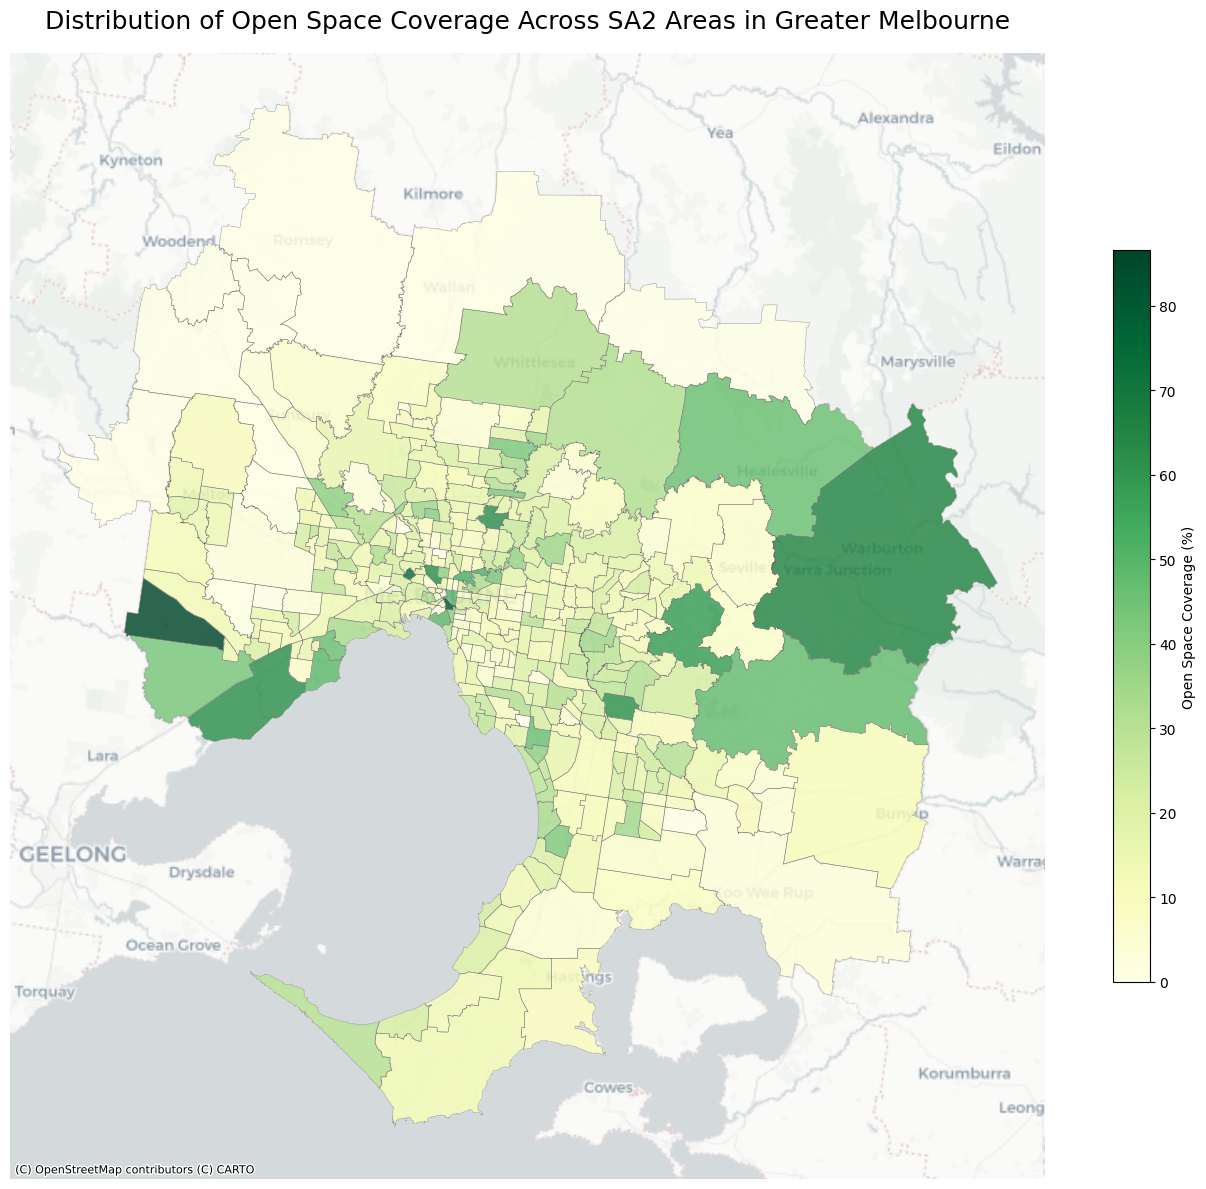

In [7]:
melb=melb.to_crs(3857)

fig,ax=plt.subplots(
    figsize=(14,12)
)

melb.plot(
    column="coverage",
    cmap="YlGn",
    linewidth=0.35,
    edgecolor="white",
    alpha=0.82,
    legend=True,
    ax=ax,
    legend_kwds={
        "label":"Open Space Coverage (%)",
        "shrink":0.65
    }
)

melb.boundary.plot(
    ax=ax,
    linewidth=0.4,
    color="black",
    alpha=0.35
)

ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

ax.set_title(
    "Distribution of Open Space Coverage Across SA2 Areas in Greater Melbourne",
    fontsize=18,
    pad=18
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "green_space_formative.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Interpretation

This map presents the spatial distribution of open space coverage across SA2 areas in Greater Melbourne. The results indicate substantial variation in the proportion of land allocated to open space throughout the metropolitan region.

Higher open space coverage appears in several outer metropolitan and peripheral areas, while many inner and middle-ring suburbs display lower proportions. This pattern may be associated with differences in development intensity, land use allocation, and the availability of large public reserves.

In relation to the research question, the findings suggest that green space is not evenly distributed across Greater Melbourne. Although this map focuses only on spatial coverage, it provides an initial indication of potential inequality in environmental amenity and accessibility. Future analysis may incorporate population data to evaluate green space per capita and better assess distribution equity.

## Declaration

I acknowledge the use of ChatGpt to help me debug my code for data analysis and generate images for this assessment.

I used it to help visualise the distribution of green space in the Melbourne metropolitan area.

A full record of prompts and outputs is available upon request.